# PotentialSystem notebook demo

Este notebook ejecuta una simulacion corta usando la configuracion JSON de `conf/notebook/fourier/test/v_1.json` y la API reutilizable de `workflows_api`. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [2]:
%matplotlib inline
from config import load_fourier_config
from workflows_api import make_system, plot_fft_phi, run_workflow
from config_logging import configure_logging

configure_logging()

# Perfil reducido para ejecucion interactiva rapida en notebook.
config = load_fourier_config(config_group='test', config_version='v_1', version='notebook_demo')
params = config.cases()[0]

system = make_system(params)

2026-07-02 00:03:14 | INFO     | MainProcess | workflows.params | Building system: method=poincare_gc traj=gc A=0.7 rho=0.1 Ntraj=12 Tf=3
2026-07-02 00:03:14 | INFO     | MainProcess | classes.fourier_system | Initializing FourierSystem: traj=gc M=6 A=0.7 rho=0.1 eta=0.1 Ntraj=12 Tf=3
2026-07-02 00:03:14 | INFO     | MainProcess | classes.fourier_system | FourierSystem initialized with 22 active Fourier modes


In [3]:
_ = system.initial_conditions(type=system.init)

2026-07-02 00:03:14 | INFO     | MainProcess | classes.fourier_system | Generating initial conditions: type=selected traj=gc Ntraj=12
2026-07-02 00:03:14 | INFO     | MainProcess | classes.fourier_system | Using selected initial conditions with 12 trajectories
2026-07-02 00:03:14 | INFO     | MainProcess | classes.fourier_system | Initial condition vector ready: shape=(24,)


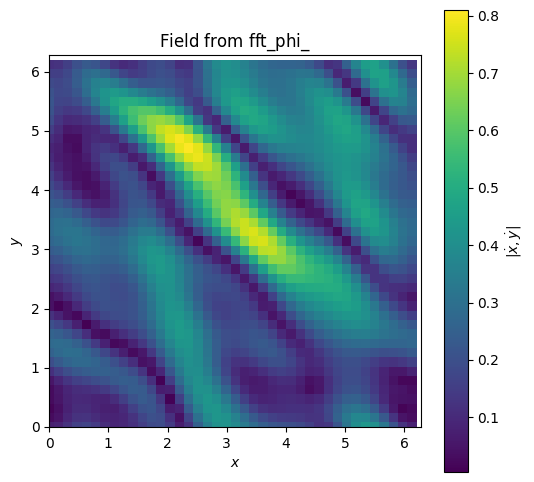

In [4]:
_ = plot_fft_phi(system, kind='magnitude')

In [5]:
result = run_workflow(system, plot=False)

2026-07-02 00:03:15 | INFO     | MainProcess | workflows.workflow | Running notebook case: plot=False save=True
2026-07-02 00:03:15 | INFO     | MainProcess | classes.fourier_system | Generating initial conditions: type=selected traj=gc Ntraj=12
2026-07-02 00:03:15 | INFO     | MainProcess | classes.fourier_system | Using selected initial conditions with 12 trajectories
2026-07-02 00:03:15 | INFO     | MainProcess | classes.fourier_system | Initial condition vector ready: shape=(24,)
2026-07-02 00:03:15 | INFO     | MainProcess | workflows.integration | Initial conditions ready: shape=(24,) init=selected
2026-07-02 00:03:15 | INFO     | MainProcess | workflows.integration | Starting integration: method=poincare_gc traj=gc A=0.7 rho=0.1 Ntraj=12 Tf=3 solver=BM4 step=0.1 samples=4
2026-07-02 00:03:15 | INFO     | MainProcess | workflows.integration | Using guiding-center integrator: solve_ivp_sympext
2026-07-02 00:03:15 | INFO     | MainProcess | workflows.integration | solve_ivp_sympext

In [6]:
result.get_trayectorys()

array([[[0.5       , 4.5       ],
        [0.48899077, 4.66993413],
        [0.4617989 , 4.89244374],
        [0.37853408, 5.183476  ]],

       [[0.54545455, 4.5       ],
        [0.52543008, 4.65809956],
        [0.49309766, 4.86593592],
        [0.41528205, 5.14276129]],

       [[0.59090909, 4.5       ],
        [0.56226239, 4.64850635],
        [0.52399706, 4.84362722],
        [0.44897974, 5.10669022]],

       [[0.63636364, 4.5       ],
        [0.59941451, 4.64122461],
        [0.55463044, 4.82587093],
        [0.47991711, 5.07649505]],

       [[0.68181818, 4.5       ],
        [0.63680437, 4.63613037],
        [0.58506605, 4.8125884 ],
        [0.50854018, 5.05259554]],

       [[0.72727273, 4.5       ],
        [0.67434571, 4.63298987],
        [0.61531317, 4.80343591],
        [0.53527932, 5.03484315]],

       [[0.77272727, 4.5       ],
        [0.71195034, 4.63152791],
        [0.64533981, 4.79794083],
        [0.56047839, 5.02275134]],

       [[0.81818182, 4.5       ],


In [7]:
result.get_initials_conditions()

array([[0.5       , 4.5       ],
       [0.54545455, 4.5       ],
       [0.59090909, 4.5       ],
       [0.63636364, 4.5       ],
       [0.68181818, 4.5       ],
       [0.72727273, 4.5       ],
       [0.77272727, 4.5       ],
       [0.81818182, 4.5       ],
       [0.86363636, 4.5       ],
       [0.90909091, 4.5       ],
       [0.95454545, 4.5       ],
       [1.        , 4.5       ]])

2026-07-02 00:03:15 | INFO     | MainProcess | classes.simulation_result | Plotting Poincare section: traj=gc modulo=True


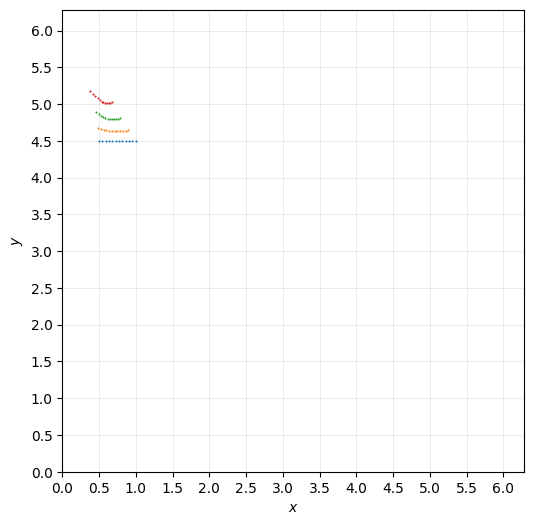

In [8]:
_ = result.plot_poincare(decimal_grid = True)